# Cognitive Load Performance Analysis (Guided Notebook)
End-to-end reproduction using **R (lmerTest + emmeans via rpy2)** for LMEs and Python for correlations/plots. Outputs match the manuscript tables and figures.

## 0. Setup & Imports

In [ ]:

import os, sys, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path

# Ensure this directory is importable (so analysis_utils.py is found)
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Output directories
Path("figs/figure_1_perf_corr/task_metrics").mkdir(parents=True, exist_ok=True)
Path("tables").mkdir(parents=True, exist_ok=True)

# Import utils
from performance_utils import (
    ensure_condition_order, lme_contrast_table_r, build_tlx_lme_table_r, build_within_subject_corr_table,
    prep_perf_long, summarise_perf, make_wide, corr_with_pvalues
)
print("[OK] Environment ready.")

[OK] Environment ready.


## 1. Config

In [2]:

EXP_CSV  = "data/out/performance_exp.csv"
BSL_CSV  = "data/out/performance_bsl.csv"
NASA_CSV = "data/out/aggregated_nasatlx.csv"

ACCURACY_COLS = ["track_point_accuracy","resman_point_accuracy","sysmon_point_accuracy","comms_point_accuracy"]
RT_COLS = [("mean_sysmon_response_time","System Monitoring RT (ms)"),
           ("mean_comms_response_time","Communications RT (ms)")]
print("[OK] Config loaded.")

[OK] Config loaded.


## 2. Load & Harmonize

In [3]:

exp  = pd.read_csv(EXP_CSV)
bsl  = pd.read_csv(BSL_CSV)
nasa = pd.read_csv(NASA_CSV)

exp  = ensure_condition_order(exp)
bsl  = ensure_condition_order(bsl)
nasa = ensure_condition_order(nasa)

# Convert communications RT to ms if needed
if "mean_comms_response_time" in exp.columns:
    exp["mean_comms_response_time"] = exp["mean_comms_response_time"] * 1000.0
if "mean_comms_response_time" in bsl.columns:
    bsl["mean_comms_response_time"] = bsl["mean_comms_response_time"] * 1000.0

exp.head(2), bsl.head(2), nasa.head(2)

(   participant condition  window_start  window_end  track_point_accuracy  \
 0          415         H             0          60              0.910953   
 1          415         H            30          90              0.953079   
 
    resman_point_accuracy  sysmon_point_accuracy  comms_point_accuracy  \
 0                    1.0               0.846154                   1.0   
 1                    1.0               1.000000                   1.0   
 
    mean_sysmon_response_time  mean_comms_response_time  window_index  
 0                     2800.0                  2256.309             0  
 1                     2180.0                  2376.669             1  ,
    participant condition  window_start  window_end  track_point_accuracy  \
 0          427         H             0          60              0.862762   
 1          427         H            30          90              0.812656   
 
    resman_point_accuracy  sysmon_point_accuracy  comms_point_accuracy  \
 0               0.

## 3. LME Contrast Tables via R (Experimental & Baseline)

In [4]:
exp_tab = lme_contrast_table_r(exp, ACCURACY_COLS, RT_COLS, label_prefix="Experimental blocks")
bsl_tab = lme_contrast_table_r(bsl, ACCURACY_COLS, RT_COLS, label_prefix="Baseline blocks")

print("\n" + "="*80); print("Experimental blocks (LaTeX)"); print("="*80)
print(exp_tab.to_latex(index=False, escape=False,
      caption="Experimental blocks: L–M, M–H, and L–H contrasts ($\beta$, p).",
      label="tab:experimental_blocks"))
print("\n" + "="*80); print("Baseline blocks (LaTeX)"); print("="*80)
print(bsl_tab.to_latex(index=False, escape=False,
      caption="Baseline blocks: L–M, M–H, and L–H contrasts ($\beta$, p).",
      label="tab:baseline_blocks"))

# Save to disk
open("tables/experimental_performance.tex","w").write(exp_tab.to_latex(index=False, escape=False,
    caption="Experimental blocks: L–M, M–H, and L–H contrasts ($\beta$, p).", label="tab:experimental_blocks"))
open("tables/baseline_performance.tex","w").write(bsl_tab.to_latex(index=False, escape=False,
    caption="Baseline blocks: L–M, M–H, and L–H contrasts ($\beta$, p).", label="tab:baseline_blocks"))
print("[✓] Saved performance tables to tables/*.tex")

R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3225' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3225' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3225' (or larger)
[or, globally,


=== track_point_accuracy (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: -7264.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-7.0499 -0.3289  0.0340  0.5323  6.7870 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.006405 0.08003 
 Residual                   0.005568 0.07462 
Number of obs: 3225, groups:  participant_id, 72

Fixed effects:
               Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)   9.318e-01  9.758e-03  7.828e+01   95.49   <2e-16 ***
condition.L  -7.369e-02  2.271e-03  3.150e+03  -32.45   <2e-16 ***
condition.Q  -2.769e-02  2.286e-03  3.151e+03  -12.11   <2e-16 ***
window_index -4.013e-04  3.041e-04  3.150e+03   -1.32    0.187    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

C

R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3225' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3225' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3225' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3225)' or larger];
but be warned that this may result in large computatio


=== comms_point_accuracy (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 3848.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.4776 -0.9732  0.1049  0.9431  2.0206 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.005345 0.07311 
 Residual                   0.187954 0.43354 
Number of obs: 3225, groups:  participant_id, 72

Fixed effects:
               Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)   4.861e-01  1.690e-02  3.205e+02  28.764   <2e-16 ***
condition.L   1.483e-01  1.319e-02  3.150e+03  11.243   <2e-16 ***
condition.Q  -1.209e-02  1.327e-02  3.163e+03  -0.911   0.3622    
window_index  4.099e-03  1.767e-03  3.150e+03   2.320   0.0204 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Co

R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'pbkrtest.limit = 3225' (or larger)
[or, globally, 'set emm_options(pbkrtest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: Note: D.f. calculations have been disabled because the number of observations exceeds 3000.
To enable adjustments, add the argument 'lmerTest.limit = 3225' (or larger)
[or, globally, 'set emm_options(lmerTest.limit = 3225)' or larger];
but be warned that this may result in large computation time and memory use.
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  



=== track_point_accuracy (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: -1325.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.9495 -0.3366  0.0662  0.5020  4.0242 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.010943 0.10461 
 Residual                   0.005122 0.07157 
Number of obs: 645, groups:  participant_id, 72

Fixed effects:
               Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)   9.161e-01  1.311e-02  8.195e+01  69.880  < 2e-16 ***
condition.L  -7.244e-02  4.895e-03  5.703e+02 -14.799  < 2e-16 ***
condition.Q  -2.551e-02  4.878e-03  5.701e+02  -5.229  2.4e-07 ***
window_index -6.066e-04  3.451e-03  5.700e+02  -0.176    0.861    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Co

R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  



=== sysmon_point_accuracy (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 506.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.8617 -0.4879  0.2660  0.6607  1.8645 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 0.0281   0.1676  
 Residual                   0.1090   0.3301  
Number of obs: 645, groups:  participant_id, 72

Fixed effects:
               Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)   7.726e-01  2.851e-02  1.465e+02  27.098  < 2e-16 ***
condition.L  -9.264e-03  2.256e-02  5.716e+02  -0.411 0.681535    
condition.Q  -1.689e-05  2.249e-02  5.707e+02  -0.001 0.999401    
window_index -5.722e-02  1.592e-02  5.702e+02  -3.595 0.000353 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Cor

R callback write-console: fixed-effect model matrix is rank deficient so dropping 1 column / coefficient
  



=== Communications RT (ms) (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 11254.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9571 -0.2443  0.2059  0.5854  2.4092 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept)  450347   671.1  
 Residual                   2117860  1455.3  
Number of obs: 645, groups:  participant_id, 72

Fixed effects:
             Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)   3121.20     120.28  158.07  25.949  < 2e-16 ***
condition.L    532.12      99.47  571.59   5.350 1.28e-07 ***
condition.Q   -126.67      99.17  570.61  -1.277    0.202    
window_index   -84.06      70.18  570.11  -1.198    0.232    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effe

## 4. NASA-TLX LMEs & Within-Subject Correlations

In [5]:

# TLX total
TLX_SUBSCALES = ["mental_demand","physical_demand","time_pressure","performance","effort","frustration"]
nasa = nasa.copy(); nasa["tlx_total"] = nasa[TLX_SUBSCALES].sum(axis=1)

# LME table via R
tlx_tab = build_tlx_lme_table_r(nasa)
print("\n" + "="*80); print("NASA-TLX (LaTeX)"); print("="*80)
print(tlx_tab.to_latex(index=False, escape=False,
      caption="NASA-TLX subscales and total: L–M, M–H, L–H contrasts (β, p).",
      label="tab:tlx_lme_contrasts"))
open("tables/nasatlx_lme.tex","w").write(tlx_tab.to_latex(index=False, escape=False,
    caption="NASA-TLX subscales and total: L–M, M–H, L–H contrasts (β, p).", label="tab:tlx_lme_contrasts"))

# Within-subject corr (accuracy ↔ TLX) on experimental blocks
merged = exp.merge(nasa[["participant","condition"] + TLX_SUBSCALES + ["tlx_total"]],
                   on=["participant","condition"], how="inner")
corr_tab = build_within_subject_corr_table(merged)
print("\n" + "="*80); print("Within-subject correlations (LaTeX)"); print("="*80)
print(corr_tab.to_latex(index=False, escape=False,
      caption="Within-subject (demeaned) correlations between accuracy and NASA-TLX subscales (and total).",
      label="tab:tlx_within_subject_corrs"))
open("tables/within_subject_corrs.tex","w").write(corr_tab.to_latex(index=False, escape=False,
    caption="Within-subject (demeaned) correlations between accuracy and NASA-TLX subscales (and total).",
    label="tab:tlx_within_subject_corrs"))
print("[✓] Saved TLX tables")

R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  



=== NASA mental_demand (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 772.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7972 -0.3746  0.0691  0.5358  2.5022 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 1.269    1.126   
 Residual                   1.309    1.144   
Number of obs: 216, groups:  participant_id, 72

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)   7.6104     0.1539  71.0045  49.454  < 2e-16 ***
condition.L   0.7206     0.1345 142.1691   5.357 3.32e-07 ***
condition.Q   0.2263     0.1357 142.5083   1.668   0.0976 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) cndt.L
condition.L -0.003       
condition.Q

R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  
R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  



=== NASA performance (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 864.4

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.98533 -0.55372 -0.06418  0.53303  2.71711 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 2.649    1.628   
 Residual                   1.810    1.346   
Number of obs: 216, groups:  participant_id, 72

Fixed effects:
             Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)   4.98594    0.21255  71.00339  23.458   <2e-16 ***
condition.L   0.07473    0.15817 142.12279   0.472    0.637    
condition.Q  -0.06501    0.15958 142.36878  -0.407    0.684    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) cndt.L
condition.L -0.002   

R callback write-console: fixed-effect model matrix is rank deficient so dropping 2 columns / coefficients
  



=== NASA tlx_total (R lmerTest) ===
Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: dv ~ condition + session_order_numeric + window_index + (1 |  
    participant_id)
   Data: dat

REML criterion at convergence: 1358.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.98291 -0.49489  0.00973  0.53497  2.60399 

Random effects:
 Groups         Name        Variance Std.Dev.
 participant_id (Intercept) 26.68    5.165   
 Residual                   18.52    4.304   
Number of obs: 216, groups:  participant_id, 72

Fixed effects:
            Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)  36.4428     0.6755  71.0027  53.948  < 2e-16 ***
condition.L   3.3990     0.5059 142.1236   6.719  4.1e-10 ***
condition.Q   1.3773     0.5104 142.3728   2.698  0.00781 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) cndt.L
condition.L -0.002       
cond

## 5. Figure 1 Bars: Accuracy & Mean RT (Baseline vs Experimental)

/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Performance/analysis_utils.py:295: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Performance/analysis_utils.py:295: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Users/cartersale/Documents/Research/Manuscripts/MATB_Nature/Performance/analysis_utils.py:298: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/Use

[✓] Saved: figs/figure_1_perf_corr/task_metrics/combined_accuracy_rt.svg


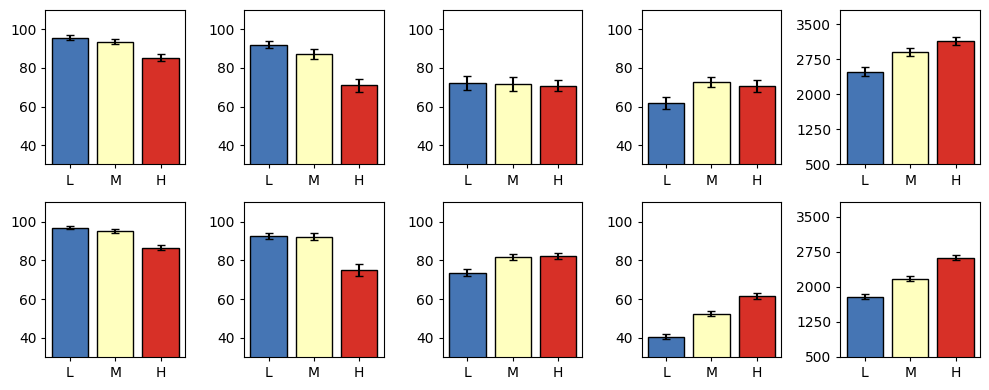

In [6]:
# Prepare
exp_fig = exp.copy(); bsl_fig = bsl.copy()
exp_fig["session"] = "Main"; bsl_fig["session"] = "Pre"
cond_map = {'L': 'Low', 'M': 'Moderate', 'H': 'High'}
for df in (exp_fig, bsl_fig):
    df['condition'] = df['condition'].map(cond_map)
    df['session'] = df['session'].str.lower()
    df['load_level'] = pd.Categorical(df['condition'], categories=['Low','Moderate','High'], ordered=True)

for df in (exp_fig, bsl_fig):
    sysmon_ms = df["mean_sysmon_response_time"]
    comms_ms  = df["mean_comms_response_time"]
    df["mean_rt"] = (sysmon_ms + comms_ms) / 2.0 / 1000.0  # seconds

exp_long = prep_perf_long(exp_fig)
bsl_long = prep_perf_long(bsl_fig)
exp_sum  = summarise_perf(exp_long)
bsl_sum  = summarise_perf(bsl_long)

# Plot
palette = {'L': '#4575b4', 'M': '#ffffbf', 'H': '#d73027'}
subtasks = ['Tracking', 'Resource Management', 'System Monitoring', 'Communications', 'Mean RT']
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 4), sharey=False)
for col_idx, subtask in enumerate(subtasks):
    for row_idx, (sess_sum, _) in enumerate(zip([bsl_sum, exp_sum], ['Baseline', 'Experimental'])):
        ax = axes[row_idx, col_idx]
        sub_df = sess_sum[sess_sum['subtask'] == subtask]

        if subtask == 'Mean RT':
            means = sub_df['mean'] * 1000; sems = sub_df['sem'] * 1000
        else:
            means = sub_df['mean'] * 100;  sems = sub_df['sem'] * 100

        colors = [palette[l] for l in sub_df['load_level']]
        ax.bar(sub_df['load_level'].cat.codes, means, yerr=sems, capsize=3, color=colors, edgecolor='black', linewidth=1)
        ax.set_xticks([0, 1, 2]); ax.set_xticklabels(sub_df['load_level']); ax.tick_params(axis='x', length=3)
        if subtask == 'Mean RT':
            ax.set_ylim(500, 3800); ax.set_yticks([500, 1250, 2000, 2750, 3500])
        else:
            ax.set_ylim(30, 110); ax.set_yticks([40, 60, 80, 100])
        ax.tick_params(axis='y', length=3); ax.set_xlabel(''); ax.set_ylabel(''); ax.set_title('')
fig.tight_layout()
fig.savefig("figs/figure_1_perf_corr/task_metrics/combined_accuracy_rt.svg", bbox_inches='tight')
print("[✓] Saved: figs/figure_1_perf_corr/task_metrics/combined_accuracy_rt.svg")

## 6. Baseline vs Experimental: Pearson correlations (+ 3 SD filter LaTeX)

In [8]:
from scipy.stats import pearsonr, zscore

df_pre  = pd.read_csv(BSL_CSV)
df_main = pd.read_csv(EXP_CSV)

for df in [df_pre, df_main]:
    df['participant'] = df['participant'].astype(str)
    df['load_level']  = df['condition'].map({'L':'Low','M':'Moderate','H':'High'})
    df['load_level']  = pd.Categorical(df['load_level'], categories=['Low','Moderate','High'], ordered=True)

pre_agg = df_pre.groupby('participant')[
    ['track_point_accuracy','resman_point_accuracy','sysmon_point_accuracy','comms_point_accuracy']
].mean().add_suffix('_pre')

main_agg = df_main.groupby('participant')[
    ['track_point_accuracy','resman_point_accuracy','sysmon_point_accuracy','comms_point_accuracy']
].mean().add_suffix('_main')

pivoted = pd.concat([pre_agg, main_agg], axis=1).dropna()

# overall accuracy
pivoted['overall_pre']  = pivoted[[c for c in pivoted.columns if c.endswith('_pre')]].mean(axis=1)
pivoted['overall_main'] = pivoted[[c for c in pivoted.columns if c.endswith('_main')]].mean(axis=1)

task_map = {
    'track': 'track_point_accuracy',
    'resman': 'resman_point_accuracy',
    'sysmon': 'sysmon_point_accuracy',
    'comms': 'comms_point_accuracy',
    'overall': 'overall'
}

# -------- Table A: All data (no outliers removed) --------
all_results = []
for task, prefix in task_map.items():
    pre  = f"{prefix}_pre"
    main = f"{prefix}_main"
    valid = pivoted[[pre, main]].dropna()
    if len(valid) >= 2:
        r, p = pearsonr(valid[pre], valid[main])
        all_results.append({'Task': task.title(), 'r': f"{r:.3f}", 'p': f"{p:.3f}", 'n': len(valid)})
    else:
        all_results.append({'Task': task.title(), 'r': 'NA', 'p': 'NA', 'n': len(valid)})

all_df = pd.DataFrame(all_results)
print(all_df.to_latex(
    index=False,
    caption="Pearson correlations between baseline and experimental session accuracies (all data; no outliers removed).",
    label="tab:correlations_all"
))
open("tables/corr_pre_main_all.tex","w").write(all_df.to_latex(
    index=False,
    escape=False,
    caption="Pearson correlations between baseline and experimental session accuracies (all data; no outliers removed).",
    label="tab:correlations_all"
))
print("[✓] Saved: tables/corr_pre_main_all.tex")

# (Optional console summary to mirror your existing printout)
print("\n=== Pearson Correlations (Pre vs. Main, all data) ===")
for row in all_results:
    print(f"{row['Task']} accuracy: r = {row['r']}, p = {row['p']} (n = {row['n']})")

# -------- Table B: 3 SD filter (existing) --------
results = []
for task, prefix in task_map.items():
    pre  = f"{prefix}_pre"
    main = f"{prefix}_main"
    valid = pivoted[[pre, main]].dropna()
    if len(valid) >= 2:
        zs = pd.DataFrame(zscore(valid[[pre, main]]), columns=[pre, main], index=valid.index)
        keep = (zs[pre].abs() < 3) & (zs[main].abs() < 3)
        filtered = valid[keep]
        if len(filtered) >= 2:
            r, p = pearsonr(filtered[pre], filtered[main])
            results.append({'Task': task.title(), 'r': f"{r:.3f}", 'p': f"{p:.3f}", 'n': len(filtered)})
        else:
            results.append({'Task': task.title(), 'r': 'NA', 'p': 'NA', 'n': len(filtered)})
    else:
        results.append({'Task': task.title(), 'r': 'NA', 'p': 'NA', 'n': len(valid)})

results_df = pd.DataFrame(results)
print(results_df.to_latex(
    index=False,
    caption="Pearson correlations between baseline and experimental session accuracies (outliers >3 SD removed).",
    label="tab:correlations_3sd"
))
open("tables/corr_pre_main_3sd.tex","w").write(results_df.to_latex(
    index=False,
    escape=False,
    caption="Pearson correlations between baseline and experimental session accuracies (outliers >3 SD removed).",
    label="tab:correlations_3sd"
))
print("[✓] Saved: tables/corr_pre_main_3sd.tex")


\begin{table}
\caption{Pearson correlations between baseline and experimental session accuracies (all data; no outliers removed).}
\label{tab:correlations_all}
\begin{tabular}{lllr}
\toprule
Task & r & p & n \\
\midrule
Track & 0.840 & 0.000 & 72 \\
Resman & 0.489 & 0.000 & 72 \\
Sysmon & 0.494 & 0.000 & 72 \\
Comms & 0.752 & 0.000 & 72 \\
Overall & 0.753 & 0.000 & 72 \\
\bottomrule
\end{tabular}
\end{table}

[✓] Saved: tables/corr_pre_main_all.tex

=== Pearson Correlations (Pre vs. Main, all data) ===
Track accuracy: r = 0.840, p = 0.000 (n = 72)
Resman accuracy: r = 0.489, p = 0.000 (n = 72)
Sysmon accuracy: r = 0.494, p = 0.000 (n = 72)
Comms accuracy: r = 0.752, p = 0.000 (n = 72)
Overall accuracy: r = 0.753, p = 0.000 (n = 72)
\begin{table}
\caption{Pearson correlations between baseline and experimental session accuracies (outliers >3 SD removed).}
\label{tab:correlations_3sd}
\begin{tabular}{lllr}
\toprule
Task & r & p & n \\
\midrule
Track & 0.565 & 0.000 & 71 \\
Resman & 0.449 

## 7. Correlation heatmaps (within & cross session)

/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_49330/2523612044.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return mask.applymap(lambda pv: "*" if pd.notnull(pv) and pv < alpha else "")
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_49330/2523612044.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return mask.applymap(lambda pv: "*" if pd.notnull(pv) and pv < alpha else "")
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_49330/2523612044.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return mask.applymap(lambda pv: "*" if pd.notnull(pv) and pv < alpha else "")


[✓] Saved: figs/baseline_corr_heatmap.svg
[✓] Saved: figs/experimental_corr_heatmap.svg
[✓] Saved: figs/cross_corr_heatmap.svg


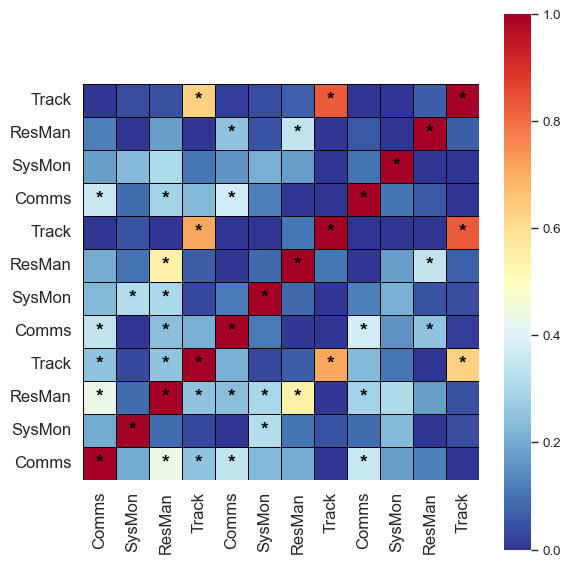

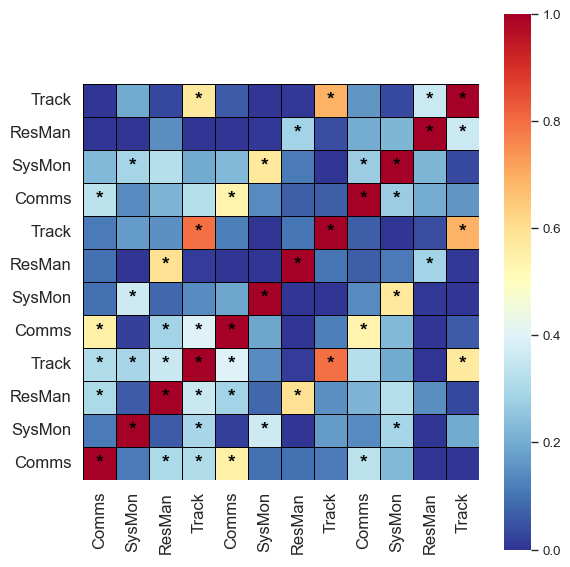

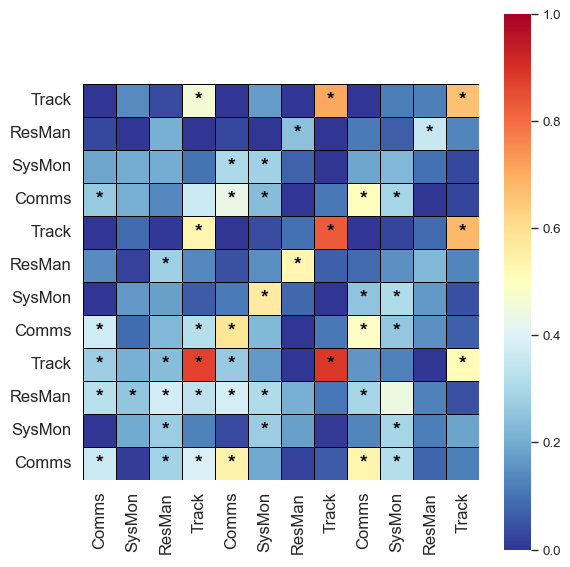

In [ ]:

import seaborn as sns

exp_h = pd.read_csv(EXP_CSV); bsl_h = pd.read_csv(BSL_CSV)
for df in (exp_h, bsl_h):
    df["participant"] = df["participant"].astype(str)
    df["condition"] = df["condition"].astype(str).str.strip()
exp_h["session"] = "main"; bsl_h["session"] = "pre"

base_df = make_wide(bsl_h)
main_df = make_wide(exp_h)
common = base_df.index.intersection(main_df.index)
base_df = base_df.loc[common]; main_df = main_df.loc[common]

base_corr, base_p  = corr_with_pvalues(base_df)
main_corr, main_p  = corr_with_pvalues(main_df)
cross_corr, cross_p = corr_with_pvalues(base_df, main_df)

def format_subtask_labels(columns): return [task for (_, task) in columns]
def significance_mask(p_matrix, alpha=0.05):
    mask = p_matrix.copy()
    if mask.shape[0] == mask.shape[1]:
        for i in range(len(mask)):
            mask.iat[i, i] = np.nan
    return mask.applymap(lambda pv: "*" if pd.notnull(pv) and pv < alpha else "")

sns.set_style("white"); sns.set_context("paper", font_scale=1.1)
mats = [(base_corr, base_p,  "baseline_corr_heatmap.svg"),
        (main_corr, main_p,  "experimental_corr_heatmap.svg"),
        (cross_corr, cross_p, "cross_corr_heatmap.svg")]
for corr_matrix, p_matrix, filename in mats:
    corr_matrix = corr_matrix[corr_matrix.columns[::-1]]
    p_matrix    = p_matrix[p_matrix.columns[::-1]]
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={"aspect": "equal"})
    sns.heatmap(corr_matrix, ax=ax, cmap="RdYlBu_r", vmin=0, vmax=1, linewidths=0.5, linecolor="black",
                xticklabels=format_subtask_labels(corr_matrix.columns),
                yticklabels=format_subtask_labels(corr_matrix.index),
                cbar=True, annot=significance_mask(p_matrix), fmt="", annot_kws={"size": 14, "weight": "bold", "color": "black"})
    ax.set_xlabel(""); ax.set_ylabel(""); ax.set_title("")
    ax.tick_params(axis="x", labelrotation=90, labelsize=12)
    ax.tick_params(axis="y", labelrotation=0,  labelsize=12)
    fig.tight_layout()
    fig.savefig(f"figs/{filename}", bbox_inches="tight")
    #plt.close(fig)
    print(f"[✓] Saved: figs/{filename}")